## Imports

In [22]:
%load_ext autoreload
%autoreload 2

import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import msml610_utils as ut
import L08_01_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux d494b817c6e2 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [24]:
import helpers.hmodule as hmodule
hmodule.install_module_if_not_present(
  "dataframe_image",
  use_activate=True,
)

Module 'dataframe_image' is already installed.


In [25]:
from cycler import cycler

default_cycler = (
    cycler(color=["0.3", "0.5", "0.7", "0.5"])
    + cycler(linestyle=["-", "--", ":", "-."])
    + cycler(marker=["o", "v", "d", "p"])
)

color = ["0.3", "0.5", "0.7", "0.5"]
linestyle = ["-", "--", ":", "-."]
marker = ["o", "v", "d", "p"]

plt.rc("font", size=20)

# Cell 1: Sales example

In [27]:
dir_name = "L08_data"
#!ls $dir_name

out_dir_name = "figures/L08"
# cp msml610/lectures_source/figures/L08/*.png msml610/lectures_source/figures/L08/

In [28]:
data = pd.read_csv(dir_name + "/xmas_sales.csv")
data["is_on_sale"] = data["is_on_sale"].astype(float)
print(data.shape)
data.head(6)

(2000, 5)


,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1.0,219.60
1,1,2,12.98,1.0,184.70
2,1,1,12.98,1.0,145.75
3,1,0,12.98,0.0,102.45
4,2,3,19.92,0.0,103.22
5,2,2,19.92,0.0,53.73


In [29]:
import helpers.hpandas_display as hpandisp
hpandisp.convert_df_to_png(data.head(6), os.path.join(out_dir_name, 'xmas_sales_df.png'), index=True,
                           print_markdown=True,
                           markdown_path_prefix="msml610/lectures_source")
# cp msml610/tutorials/figures/L09/* msml610/lectures_source/figures/L09/

INFO:helpers.hpandas_display:Converting dataframe to PNG: figures/L08/xmas_sales_df.png
INFO:helpers.hpandas_display:PNG image saved to: figures/L08/xmas_sales_df.png


![](msml610/lectures_source/figures/L08/xmas_sales_df.png)


- **Purpose**: Compare sales outcomes between stores with and without price cuts
- **What it shows**: Box plots of weekly sales amounts for treated (cut prices) and control (no price cut) groups
- **Key insight**: Visual evidence suggesting price cuts increase sales, but this may reflect confounding rather than true causal effect

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:helpers.hmatplotlib:Saved figure to figures/L08/xmas_boxplot.png


![](msml610/lectures_source/figures/L08/xmas_boxplot.png)


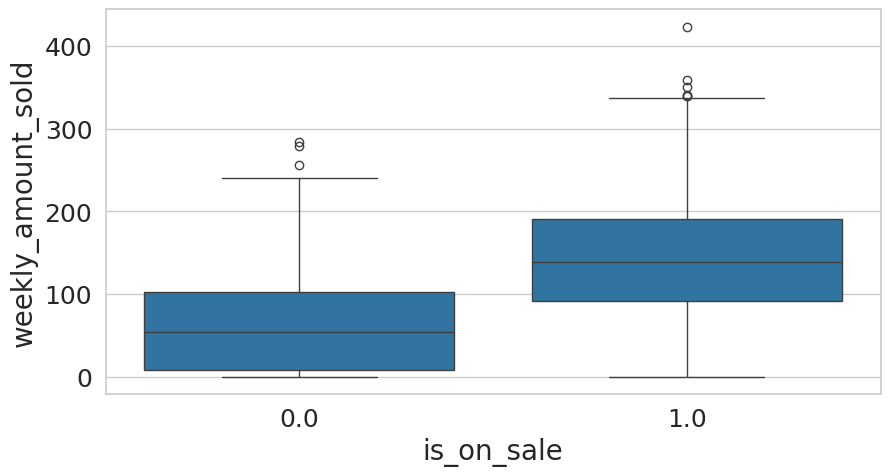

In [30]:
# TODO(ai_gp): Move to _utils.py
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.boxplot(y="weekly_amount_sold", x="is_on_sale", data=data,
            ax=ax)

ax.set_xlabel("is_on_sale", fontsize=20)
ax.set_ylabel("weekly_amount_sold", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=18)

import helpers.hmatplotlib as hmatplo
hmatplo.save_fig(fig, os.path.join(out_dir_name, "xmas_boxplot.png"),
                  print_markdown=True,
                  path_prefix="msml610/lectures_source")

## Cell 2: Conceptual Example

In [31]:
# # i = unit identifier
# # y0, y1 = outcomes under control and treatment
# # t = treatment indicator
# # x = group
# df1 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[200, 120, 300, 450, 600, 600],
#         y1=[220, 140, 400, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df1

In [32]:
# # Select the outcome based on the treatment.
# df1["y"] = (df1["t"] * df1["y1"] + (1 - df1["t"]) * df1["y0"]).astype(int)

# # Treatment effect.
# df1["te"] = df1["y1"] - df1["y0"]

# df1

In [33]:
# df2 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[
#             200,
#             120,
#             300,
#             np.nan,
#             np.nan,
#             np.nan,
#         ],
#         y1=[np.nan, np.nan, np.nan, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df2

In [34]:
# # Select the outcome based on the treatment.
# df2["y"] = (df2["t"] * df2["y1"] + (1 - df2["t"]) * df2["y0"]).astype(int)

# # Treatment effect.
# df2["te"] = df2["y1"] - df2["y0"]

# df2

## Cell 3: Visual Analysis of Bias in Sales Example

- **Purpose**: Visualize scatter points and regression lines for treated and control stores
- **What it shows**: Treated stores (red) and control stores (blue) with their respective regression trends
- **Key insight**: Within each group, the relationship between baseline sales and treatment appears similar, but overall pooled relationship is different

INFO:helpers.hmatplotlib:Saved figure to figures/L08/Association_Causation_Bias0.png


![](msml610/lectures_source/figures/L08/Association_Causation_Bias0.png)


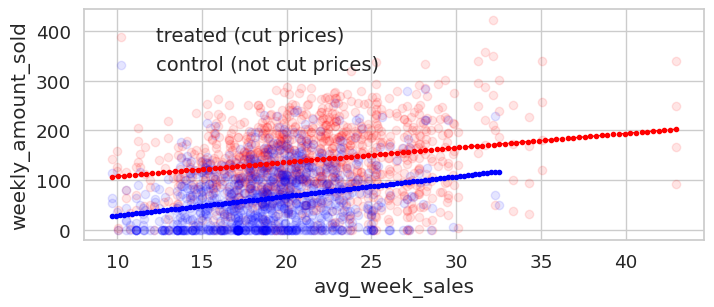

In [37]:
mtl0cireout.plot_sales_bias_analysis(data, marker)
fig = None
hmatplo.save_fig(fig, os.path.join(out_dir_name, "Association_Causation_Bias0.png"),
                  print_markdown=True,
                  path_prefix="msml610/lectures_source")

- **Purpose**: Compare pooled vs. stratified regression models with synthetic data
- **What it shows**: Left panel shows single trend line across all data; right panel shows separate trend lines for large and small businesses
- **Key insight**: Simpson's paradox emerges when aggregation obscures group-level trends; stratification reveals the true relationships

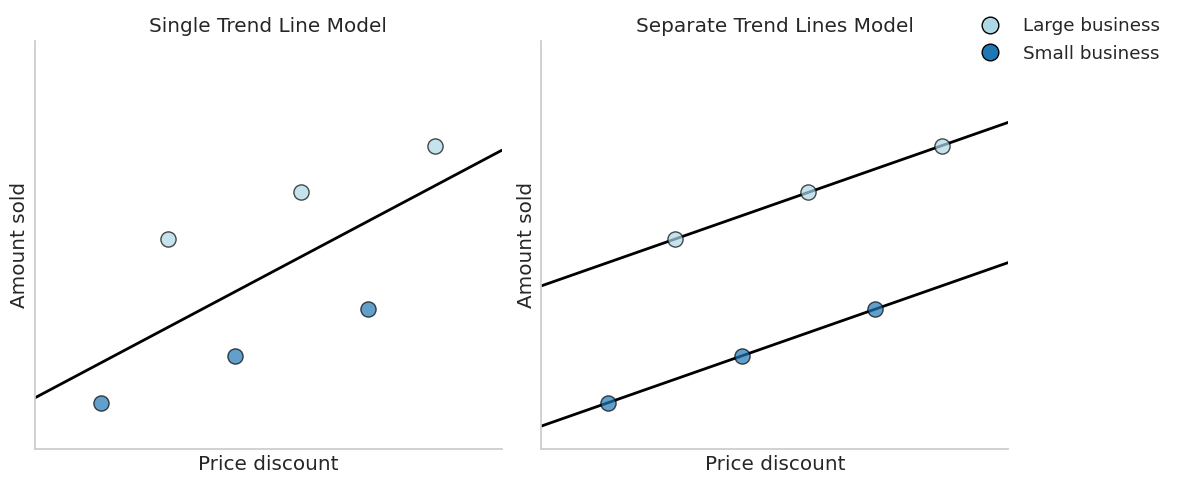

INFO:helpers.hmatplotlib:Saved figure to figures/L09/Association_Causation_Bias1.png


![](msml610/lectures_source/figures/L09/Association_Causation_Bias1.png)


In [17]:
mtl0cireout.plot_single_vs_separate_trends()
hmatplo.save_fig(fig, os.path.join(out_dir_name, "Association_Causation_Bias1.png"),
                  print_markdown=True,
                  path_prefix="msml610/lectures_source")

## Cell 4: Simpson's Paradox

- **Purpose**: Illustrate Simpson's paradox where aggregate and group-level trends contradict
- **What it shows**: Two groups (blue and red) with positive within-group trends, but negative overall trend
- **Key insight**: Ignoring confounding variables (like business size) leads to contradictory causal conclusions

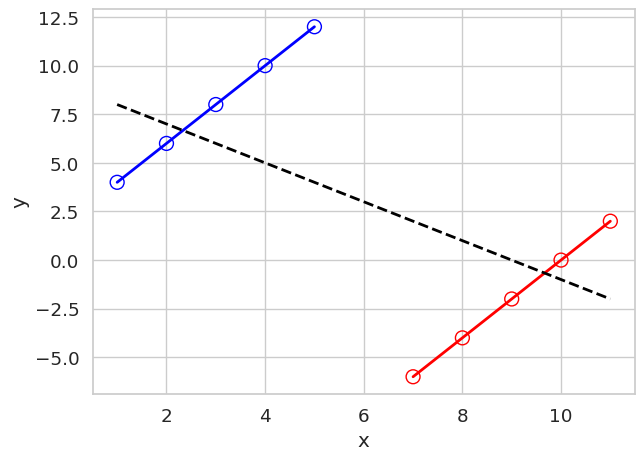

INFO:helpers.hmatplotlib:Saved figure to figures/L09/Simpson_Paradox.png


![](msml610/lectures_source/figures/L09/Simpson_Paradox.png)


In [18]:
mtl0cireout.plot_simpsons_paradox()
hmatplo.save_fig(fig, os.path.join(out_dir_name, "Simpson_Paradox.png"),
                  print_markdown=True,
                  path_prefix="msml610/lectures_source")